In [1]:
import sys
sys.path.append('/home/icclab/Documents/lqw/Multimodal_Classification/PatchwiseClsFra')

import os
os.environ['CUDA_VISIBLE_DEVICES'] = ','.join(map(str, [1]))
print('using GPU %s' % ','.join(map(str, [1])))

import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.io as sio
from scipy.stats import spearmanr

from option import opt
from loadData import data_pipe
from loadData.dataAugmentation import dataAugmentation
from models import SHNet, S2ENet, MDL, get_model_config
from models.MS2CANet2 import pymodel
from sklearn.feature_selection import f_regression, mutual_info_regression

using GPU 1


In [2]:
args = opt.get_args()
# args.dataset_name = "PaviaU"
args.dataset_name = "Houston_2013"


# args.backbone = "MS2CANet"
# args.backbone = "S2ENet"
# args.backbone = "SHNet"
args.backbone = "MDL_L"

args.split_type = "disjoint"
get_model_config(args)

print("args.backbone", args.backbone)

args.backbone MDL_L


In [3]:
# data_pipe.set_deterministic(seed = 666)
args.print_data_info = False
args.data_info_start = 1
args.show_gt = False
args.remove_zero_labels = True


if args.backbone in args.SSISO:
    transform = dataAugmentation(args.randomCrop)   # 有些模型加增强，会造成测试精度下降很多
else:
    transform = None

# create dataloader
if args.dataset_name in args.SD:
    args.train_ratio = 0.1
    args.path_data = "/home/icclab/Documents/lqw/DatasetSMD"
    img1, train_gt, test_gt, data_gt = data_pipe.get_data(args)
    print(img1.shape, train_gt.shape, test_gt.shape, data_gt.shape)
elif args.dataset_name in args.MD:
    args.train_ratio = 1
    args.path_data = "/home/icclab/Documents/lqw/DatasetMMF"
    img1, img2, train_gt, val_gt, test_gt, data_gt, GT = data_pipe.get_data(args)
    print(img1.shape, img2.shape, train_gt.shape, test_gt.shape, data_gt.shape)

    height, wigth, data1_bands = img1.shape
    height, wigth, data2_bands = img2.shape


class_num = np.max(train_gt)
pad_width = args.patch_size // 2
modality_1 = np.pad(img1, pad_width=pad_width, mode="symmetric")        # 111104
modality_1 = modality_1[:, :, pad_width:modality_1.shape[2]-pad_width]
modality_2 = np.pad(img2, pad_width=pad_width, mode="symmetric")        # 111104
modality_2 = modality_2[:, :, pad_width:modality_2.shape[2]-pad_width]
label = np.pad(data_gt, pad_width=pad_width, mode="constant", constant_values=(-1))
print("after padding img.shape, gt.shape",label.shape, modality_1.shape, modality_2.shape) 


modality_1 = modality_1[:, 1220:1683, :]
modality_2 = modality_2[:, 1220:1683, :]
label = label[:, 1220:1683]
print("after padding img.shape, gt.shape",label.shape, modality_1.shape, modality_2.shape) 

pca is not used
split_type:  disjoint 
train_ratio:  1
(357, 1913, 144) (357, 1913, 1) (357, 1913) (357, 1913) (357, 1913)
after padding img.shape, gt.shape (363, 1919) (363, 1919, 144) (363, 1919, 1)
after padding img.shape, gt.shape (363, 463) (363, 463, 144) (363, 463, 1)


In [4]:
if args.backbone == "SHNet":
    model = SHNet.SHNet(data1_bands, data2_bands, class_num,
                factors=args.factors).to(args.device)
elif args.backbone == "MS2CANet":
    FM = 64
    args.feature_dim = 256
    para_tune = False
    if args.dataset_name == "Houston_2013":
        para_tune = True                # para_tune 这个参数对于 Houston 的提升有两个点！！
    model = pymodel.pyCNN(data1_bands, data2_bands, FM=FM, para_tune=para_tune).to(args.device)
elif args.backbone == "S2ENet":
    model = S2ENet.S2ENet(data1_bands, data2_bands, class_num, \
                            patch_size=args.patch_size).to(args.device)
    
elif  args.backbone == "MDL_L":
    model = MDL.Late_fusion_CNN(data1_bands, data2_bands, class_num).to(args.device)
    params = model.parameters()
print("model: ", args.backbone)

model:  MDL_L


In [5]:
if args.backbone == "SHNet":
    args.result_dir = "/home/icclab/Documents/lqw/Multimodal_Classification/PatchwiseClsFra/result/07-30-17-25-SHNet"
# elif args.backbone == "MS2CANet":
#     args.result_dir = "/home/icclab/Documents/lqw/Multimodal_Classification/PatchwiseClsFra/result_Houston13_MD/05-25-11-34-MS2CANet"
# elif args.backbone == "S2ENet":
#     args.result_dir = "/home/icclab/Documents/lqw/Multimodal_Classification/PatchwiseClsFra/result_Houston13_MD/05-25-13-17-S2ENet"
elif args.backbone == "MDL_L":
    args.result_dir = "/home/icclab/Documents/lqw/Multimodal_Classification/PatchwiseClsFra/result/08-02-14-26-MDL_L"

path = os.path.join(args.result_dir, 'test_loss.pth')
if path != '':
    checkpoint = torch.load(path)
    model.load_state_dict(checkpoint['model'], strict=False)
    epoch_start = checkpoint['epoch'] + 1
    print('Loaded from: {}'.format(path), "start", epoch_start)

Loaded from: /home/icclab/Documents/lqw/Multimodal_Classification/PatchwiseClsFra/result/08-02-14-26-MDL_L/test_loss.pth start 91


In [6]:
# 整个传入到 GPU 中
modality_1_t = torch.tensor(modality_1).to(args.device)
modality_2_t  = torch.tensor(modality_2).to(args.device)
label_t  = torch.tensor(label).to(args.device)

modality_1_g = modality_1_t.permute(2, 0, 1).unsqueeze(0)
modality_2_g = modality_2_t.permute(2, 0, 1).unsqueeze(0)
label_g = label_t.unsqueeze(0)
print("Size",label_g.shape, modality_1_g.shape, modality_2_g.shape)

Size torch.Size([1, 363, 463]) torch.Size([1, 144, 363, 463]) torch.Size([1, 1, 363, 463])


v1, v2 torch.Size([1, 64, 92, 117]) torch.Size([1, 64, 92, 117])
v_output_1 torch.Size([1, 92, 117])
v1_s (184, 234)


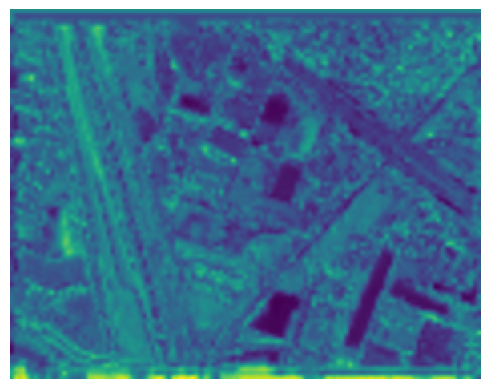

In [7]:
with torch.no_grad():
	v1, v2, v3 = model.get_visulization(modality_1_g, modality_2_g)
	print("v1, v2", v1.shape, v2.shape)

v_output_1 = torch.mean(v1, dim=1)
print("v_output_1", v_output_1.shape)

v1_s = v_output_1.permute(0, 1, 2).squeeze().cpu().numpy()
if args.backbone == "SHNet":
	v1_s = cv2.resize(v1_s, (v1.shape[3]//4, v1.shape[2]//4), cv2.INTER_LINEAR)
elif args.backbone == "MS2CANet":
	v1_s = cv2.resize(v1_s, (v1.shape[3]*2, v1.shape[2]*2), cv2.INTER_LINEAR)
elif args.backbone == "S2ENet":
	v1_s = cv2.resize(v1_s, (v1.shape[3], v1.shape[2]), cv2.INTER_LINEAR)
elif args.backbone == "MDL_L":
	v1_s = cv2.resize(v1_s, (v1.shape[3]*2, v1.shape[2]*2), cv2.INTER_LINEAR)
print("v1_s", v1_s.shape)

# plt.imshow(v1_s, cmap='gray')
plt.imshow(v1_s, cmap='viridis')
plt.axis('off')
plt.savefig(os.path.join(args.result_dir, args.backbone + 'v1.png'), bbox_inches='tight', pad_inches=0, dpi=200) 

v1, v2 torch.Size([1, 64, 92, 117]) torch.Size([1, 64, 92, 117])
v_output_1 torch.Size([1, 92, 117])
v2_s (184, 234)


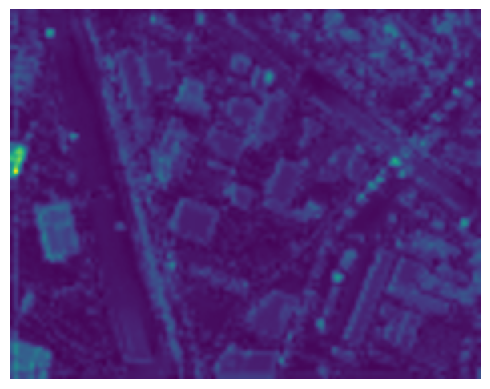

In [8]:
with torch.no_grad():
	v1, v2, v3 = model.get_visulization(modality_1_g, modality_2_g)
	print("v1, v2", v1.shape, v2.shape)

v_output_2 = torch.mean(v2, dim=1)
print("v_output_1", v_output_1.shape)
v2_s = v_output_2.permute(0, 1, 2).squeeze().cpu().numpy()
if args.backbone == "SHNet":
	v2_s = cv2.resize(v2_s, (v2.shape[3]//4, v2.shape[2]//4), cv2.INTER_LINEAR)
elif args.backbone == "MS2CANet":
	v2_s = cv2.resize(v2_s, (v2.shape[3]*2, v2.shape[2]*2), cv2.INTER_LINEAR)
elif args.backbone == "S2ENet":
	v2_s = cv2.resize(v2_s, (v2.shape[3], v2.shape[2]), cv2.INTER_LINEAR)
elif args.backbone == "MDL_L":
	v2_s = cv2.resize(v2_s, (v2.shape[3]*2, v2.shape[2]*2), cv2.INTER_LINEAR)
print("v2_s", v2_s.shape)

# plt.imshow(v2_s, cmap='gray')
plt.imshow(v2_s, cmap='viridis')
plt.axis('off')
plt.savefig(os.path.join(args.result_dir, args.backbone + 'v2.png'), bbox_inches='tight', pad_inches=0, dpi=200) 

v1, v2 torch.Size([1, 64, 92, 117]) torch.Size([1, 64, 92, 117]) torch.Size([1, 128, 92, 117])
v_output_1 torch.Size([1, 92, 117])
v3_s (184, 234)


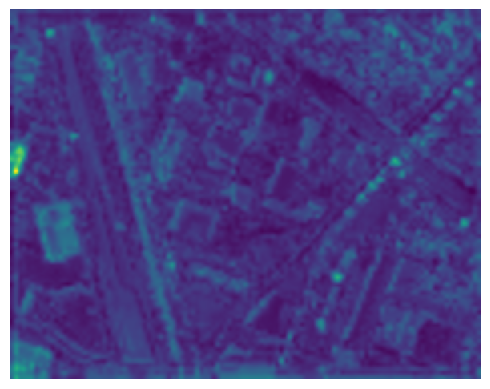

In [9]:
with torch.no_grad():
	v1, v2, v3 = model.get_visulization(modality_1_g, modality_2_g)
	# v3 = v1 + v2
	print("v1, v2", v1.shape, v2.shape, v3.shape)

v_output_3 = torch.mean(v3, dim=1)
print("v_output_1", v_output_1.shape)
v3_s = v_output_3.permute(0, 1, 2).squeeze().cpu().numpy()
if args.backbone == "SHNet":
	v3_s = cv2.resize(v3_s, (v3.shape[3]//4, v3.shape[2]//4), cv2.INTER_LINEAR)
elif args.backbone == "MS2CANet":
	v3_s = cv2.resize(v3_s, (v3.shape[3]*2, v3.shape[2]*2), cv2.INTER_LINEAR)
elif args.backbone == "S2ENet":
	v3_s = cv2.resize(v3_s, (v3.shape[3], v3.shape[2]), cv2.INTER_LINEAR)
elif args.backbone == "MDL_L":
	v3_s = cv2.resize(v3_s, (v3.shape[3]*2, v3.shape[2]*2), cv2.INTER_LINEAR)
print("v3_s", v3_s.shape)

# plt.imshow(v3_s, cmap='gray')
plt.imshow(v3_s, cmap='viridis')
plt.axis('off')
plt.savefig(os.path.join(args.result_dir, args.backbone + 'v3.png'), bbox_inches='tight', pad_inches=0, dpi=200) 

# 通道间 Pearson 相关系数热图

- 描述：
	- 左上角（HSI 自相关）
	- 右下角（LiDAR 自相关）
	- 左下 / 右上角HSI 和 LiDAR 之间互信息很低，模态互补性强，没有冗余

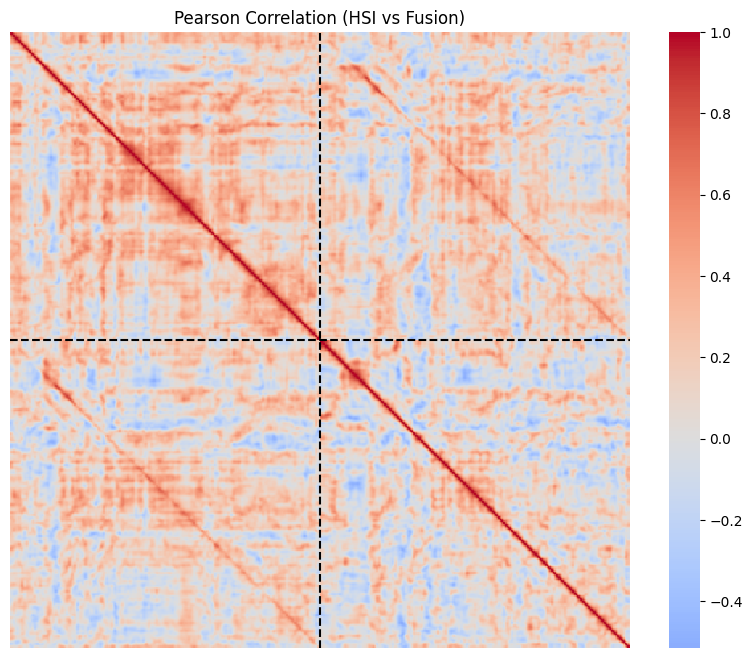

In [10]:
# 计算特征通道间的相关性
corr_matrix = np.corrcoef(v1_s.T, v3_s.T)
# corr_matrix, _ = spearmanr(v1_s, v3_s, axis=0)
# print("Correlation matrix:", corr_matrix)
# 可视化热力图
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.axvline(x=v1_s.shape[1], color='black', linestyle='--')
plt.axhline(y=v1_s.shape[1], color='black', linestyle='--')
plt.title("Pearson Correlation (HSI vs Fusion)")
plt.axis('off') 
# plt.show()
plt.savefig(os.path.join(args.result_dir, args.backbone + 'c13.png'), bbox_inches='tight', pad_inches=0, dpi=200) 

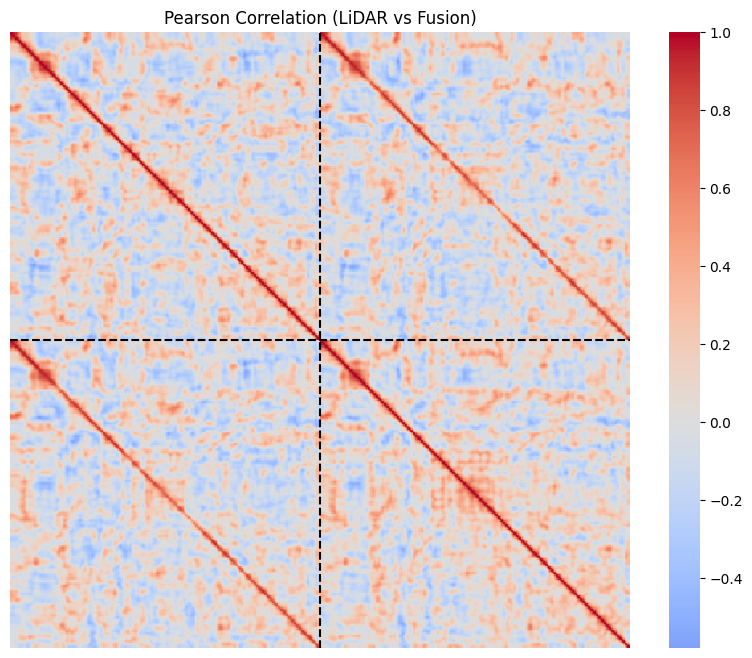

In [11]:
# 计算特征通道间的相关性
corr_matrix = np.corrcoef(v2_s.T, v3_s.T)
# corr_matrix, _ = spearmanr(v2_s, v3_s, axis=0)
# print("Correlation matrix:", corr_matrix)
# 可视化热力图
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.axvline(x=v1_s.shape[1], color='black', linestyle='--')
plt.axhline(y=v1_s.shape[1], color='black', linestyle='--')
plt.title("Pearson Correlation (LiDAR vs Fusion)")
plt.axis('off') 
# plt.show()
plt.savefig(os.path.join(args.result_dir, args.backbone + 'c23.png'), bbox_inches='tight', pad_inches=0, dpi=200) 

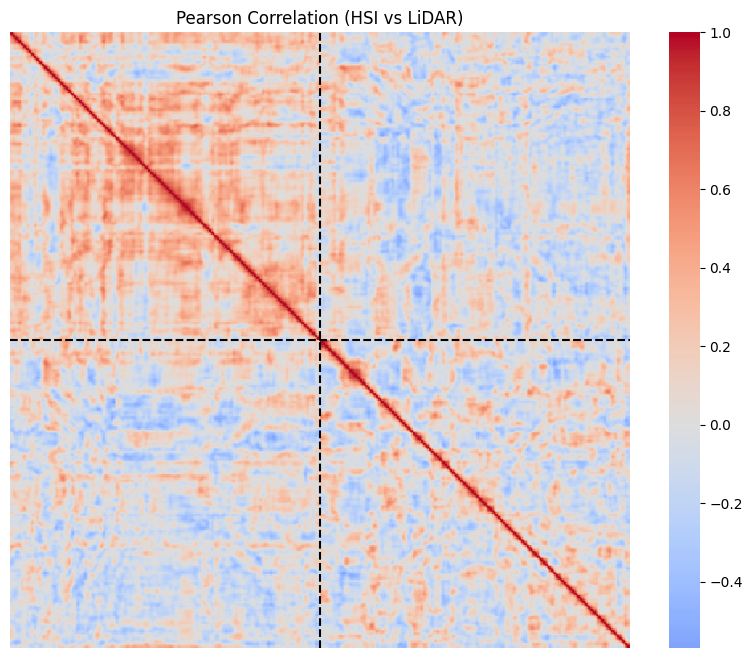

In [12]:
# 计算特征通道间的相关性
corr_matrix = np.corrcoef(v1_s.T, v2_s.T)
# corr_matrix, _ = spearmanr(v1_s, v2_s, axis=0)
# print("Correlation matrix:", corr_matrix)
# 可视化热力图
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.axvline(x=v1_s.shape[1], color='black', linestyle='--')
plt.axhline(y=v1_s.shape[1], color='black', linestyle='--')
plt.title("Pearson Correlation (HSI vs LiDAR)")
plt.axis('off') 
# plt.show()
plt.savefig(os.path.join(args.result_dir, args.backbone + 'c12.png'), bbox_inches='tight', pad_inches=0, dpi=200) 

#  Bonus：融合前后特征的互信息度量

In [13]:
# # 对应位置向量之间的 MI（可能需要归一化）
# mi_scores = []
# for i in range(v1_s.shape[1]):
#     for j in range(v2_s.shape[1]):
#         mi = mutual_info_regression(v1_s[:, [i]], v2_s[:, j])
#         mi_scores.append(mi[0])
# avg_mi = np.mean(mi_scores)
# print(f"Average mutual information between HSI and LiDAR features: {avg_mi:.4f}")

In [14]:
# # 对应位置向量之间的 MI（可能需要归一化）
# mi_scores = []
# for i in range(v1_s.shape[1]):
#     for j in range(v3_s.shape[1]):
#         mi = mutual_info_regression(v1_s[:, [i]], v3_s[:, j])
#         mi_scores.append(mi[0])
# avg_mi = np.mean(mi_scores)
# print(f"Average mutual information between HSI and LiDAR features: {avg_mi:.4f}")

In [15]:
# # 对应位置向量之间的 MI（可能需要归一化）
# mi_scores = []
# for i in range(v2_s.shape[1]):
#     for j in range(v3_s.shape[1]):
#         mi = mutual_info_regression(v2_s[:, [i]], v3_s[:, j])
#         mi_scores.append(mi[0])
# avg_mi = np.mean(mi_scores)
# print(f"Average mutual information between HSI and LiDAR features: {avg_mi:.4f}")